# Study 9: NULL model — length scale pinned at 10, VBMC over (mu_0, sigma)

Null (distance-blind) counterpart of `model-study9-vbmc-laplace.ipynb`: the GP length scale is
PINNED at `LS_NULL = 10` (>> the feature-cloud diameter ~0.78, so the RBF kernel is effectively
constant — training a region elevates coherence UNIFORMLY across the embedding), and VBMC infers
the 2-D posterior over `phi2 = [mu_0, log_sigma]` only (`inference.run_vbmc_fixed_ls` /
`run_vbmc_free_shapes_fixed_ls`).

This gives the flat model in `model-comparison-gp-vs-flat.ipynb` its OWN maximum over
`(mu_0, sigma)` instead of borrowing the fitted run's values (the caveat noted there). Everything
else matches the main notebook: same data, same Laplace `log Z` objective, same priors on
`mu_0` / `log_sigma`, both the fixed-shapes and profiled (fitted) linking-shape variants.

Results are cached in `results/study9-vbmc-laplace-null/` — delete a file to refit.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import matplotlib.pyplot as plt

import inference as inf   # Laplace + VBMC machinery (sets jax x64; import before other jax users)

LS_NULL   = 10.0          # pinned length scale, >> cloud diameter ~0.78 -> constant kernel
MAX_EVALS = 300
RESULTS_DIR = os.path.join('results', 'study9-vbmc-laplace-null')
os.makedirs(RESULTS_DIR, exist_ok=True)

geom = inf.load_geometry()
J = geom['J']
test_feature_names, test_trait = geom['test_feature_names'], geom['test_trait']
responses_cond, _ = inf.load_responses('../../data/study9.csv')
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in inf.CONDITIONS}
N_cond   = {c: int(responses_cond[c].shape[0]) for c in inf.CONDITIONS}
for c in inf.CONDITIONS:
    print(f"  {c:<14}: {N_cond[c]} participants  mean rating={np.array(responses_cond[c]).mean():.3f}")

  diet          : 101 participants  mean rating=0.528
  personality   : 101 participants  mean rating=0.555
  physical      : 101 participants  mean rating=0.593
  heterogeneous : 99 participants  mean rating=0.543


## 1. Sanity check: Laplace `log Z` at the pinned length scale

Reference `(mu_0, sigma)`; the Hessian should be PD and Newton converged. Note the
posterior-mode coherence `pz1` is (near-)constant across test features within a condition —
that is the null model's defining property.

In [2]:
cond_data = inf.prepare_all_conditions(geom, responses_cond)   # fixed default linking shapes
REF_MU, REF_SIGMA = 0.0, 1.5

total_logZ = 0.0
for c in inf.CONDITIONS:
    logZ, y_hat, ok = inf.laplace_log_Z(cond_data[c], LS_NULL, REF_MU, REF_SIGMA)
    total_logZ += logZ
    pz1_mode = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    print(f"  {c:<14}: log_Z={logZ:10.1f}  Hessian PD & converged={ok}  "
          f"pz1 range=[{pz1_mode.min():.3f}, {pz1_mode.max():.3f}]")
print(f"total log_Z at (ls={LS_NULL}, mu_0={REF_MU}, sigma={REF_SIGMA}): {total_logZ:.1f}")

  diet          : log_Z=    -523.8  Hessian PD & converged=True  pz1 range=[0.494, 0.564]
  personality   : log_Z=    -446.3  Hessian PD & converged=True  pz1 range=[0.558, 0.631]
  physical      : log_Z=    -710.6  Hessian PD & converged=True  pz1 range=[0.627, 0.653]


  heterogeneous : log_Z=    -535.3  Hessian PD & converged=True  pz1 range=[0.549, 0.589]
total log_Z at (ls=10.0, mu_0=0.0, sigma=1.5): -2216.0


## 2. 2-D VBMC over `phi2 = [mu_0, log_sigma]`, FIXED linking shapes

Same priors and box as the 3-D fit minus the length-scale coordinate. Cached to
`results/study9-vbmc-laplace-null/posterior.npz` (`ls_samples` is the pinned constant).

In [3]:
POSTERIOR_PATH = os.path.join(RESULTS_DIR, 'posterior.npz')

if os.path.exists(POSTERIOR_PATH):
    z = np.load(POSTERIOR_PATH, allow_pickle=True)
    fit = {k: z[k] for k in ('ls_samples', 'mu0_samples', 'sigma_samples')}
    fit.update(json.loads(str(z['meta'])))
    print(f"loaded cached posterior from {POSTERIOR_PATH}  ({fit['convergence_status']})")
else:
    fit = inf.run_vbmc_fixed_ls(cond_data, LS_NULL, max_evals=MAX_EVALS)
    np.savez_compressed(
        POSTERIOR_PATH,
        ls_samples=fit['ls_samples'], mu0_samples=fit['mu0_samples'], sigma_samples=fit['sigma_samples'],
        meta=json.dumps({k: fit[k] for k in ('elbo', 'func_count', 'convergence_status', 'runtime_s')}))
    print(f"saved posterior to {POSTERIOR_PATH}")

Reshaping x0 to row vector.


Reshaping lower bounds to (1, 2).


Reshaping upper bounds to (1, 2).


Reshaping plausible lower bounds to (1, 2).


Reshaping plausible upper bounds to (1, 2).


...

    39        205       -2159.98         0.11         0.00       11      0.185     stable


   inf        205       -2159.96         0.11         0.00       50      0.185     finalize


Inference terminated: variational solution stable for options.tol_stable_count fcn evaluations.


Estimated ELBO: -2159.955 +/-0.106.


saved posterior to results/study9-vbmc-laplace-null/posterior.npz


## 3. 2-D VBMC with the linking shapes PROFILED OUT (fitted shapes)

Same objective treatment as section 7a of the main notebook (`total_log_lik_free_shapes`);
only the length scale is pinned. This is the posterior the model-comparison notebook consumes.
Cached to `results/study9-vbmc-laplace-null/posterior-fitted-shapes.npz`.

In [4]:
POSTERIOR_FITTED_PATH = os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz')

if os.path.exists(POSTERIOR_FITTED_PATH):
    z = np.load(POSTERIOR_FITTED_PATH, allow_pickle=True)
    fit_f = {k: z[k] for k in ('ls_samples', 'mu0_samples', 'sigma_samples')}
    fit_f.update(json.loads(str(z['meta'])))
    print(f"loaded cached posterior from {POSTERIOR_FITTED_PATH}  ({fit_f['convergence_status']})")
else:
    fit_f = inf.run_vbmc_free_shapes_fixed_ls(geom, responses_cond, LS_NULL, max_evals=MAX_EVALS)
    np.savez_compressed(
        POSTERIOR_FITTED_PATH,
        ls_samples=fit_f['ls_samples'], mu0_samples=fit_f['mu0_samples'], sigma_samples=fit_f['sigma_samples'],
        meta=json.dumps({k: fit_f[k] for k in ('elbo', 'func_count', 'convergence_status', 'runtime_s')}))
    print(f"saved posterior to {POSTERIOR_FITTED_PATH}")

Reshaping x0 to row vector.


Reshaping lower bounds to (1, 2).


Reshaping upper bounds to (1, 2).


Reshaping plausible lower bounds to (1, 2).


Reshaping plausible upper bounds to (1, 2).


...

   inf        300         899.23         1.71         0.13       50       1.02     finalize


Inference terminated: reached maximum number of function evaluations options.max_fun_evals.


Estimated ELBO: 899.226 +/-1.713.


Caution: Returned variational solution may have not converged.


saved posterior to results/study9-vbmc-laplace-null/posterior-fitted-shapes.npz


## 4. Posteriors over `(mu_0, sigma)`: fixed vs fitted shapes

fixed shapes : convergence=probable  (evals 205, ELBO -2160.0)
fitted shapes: convergence=no  (evals 300, ELBO 899.2)
param                     fixed shapes               fitted shapes
mu_0            -0.010 [-1.485, 1.601]      -0.010 [-0.403, 0.177]
sigma             7.699 [6.790, 7.986]        0.412 [0.281, 0.542]


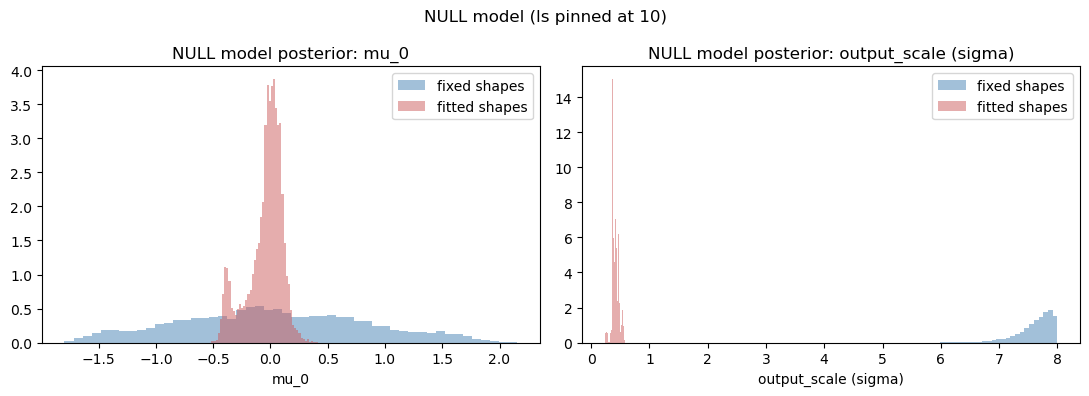

In [5]:
for lbl, f in [('fixed shapes ', fit), ('fitted shapes', fit_f)]:
    print(f"{lbl}: convergence={f['convergence_status']}  (evals {f['func_count']}, ELBO {f['elbo']:.1f})")
print(f"{'param':<10}{'fixed shapes':>28}{'fitted shapes':>28}")
for name, key in [('mu_0', 'mu0_samples'), ('sigma', 'sigma_samples')]:
    def fmt(s): return f"{np.median(s):7.3f} [{np.percentile(s,2.5):.3f}, {np.percentile(s,97.5):.3f}]"
    print(f"{name:<10}{fmt(fit[key]):>28}{fmt(fit_f[key]):>28}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, name in zip(axes, ['mu0_samples', 'sigma_samples'], ['mu_0', 'output_scale (sigma)']):
    ax.hist(fit[key], bins=50, density=True, color='steelblue', alpha=0.5, label='fixed shapes')
    ax.hist(fit_f[key], bins=50, density=True, color='indianred', alpha=0.5, label='fitted shapes')
    ax.set_xlabel(name); ax.set_title(f'NULL model posterior: {name}'); ax.legend()
plt.suptitle(f'NULL model (ls pinned at {LS_NULL:g})')
plt.tight_layout(); plt.show()

## 5. Fitted shapes at the posterior median + forward pass

As in section 7c of the main notebook: fitted per-feature linking shapes at the
posterior-median `(mu_0, sigma)` (saved for comparison), then predicted vs empirical
prevalence per condition. Under the null the coherence `pz1` is constant within a condition,
so all predictive structure comes from the per-feature shapes.

Forward pass at posterior median: ls=10 (pinned), mu_0=-0.010, sigma=0.412


saved fitted shapes to results/study9-vbmc-laplace-null/fitted-link-shapes.csv (+ .npz with theta)


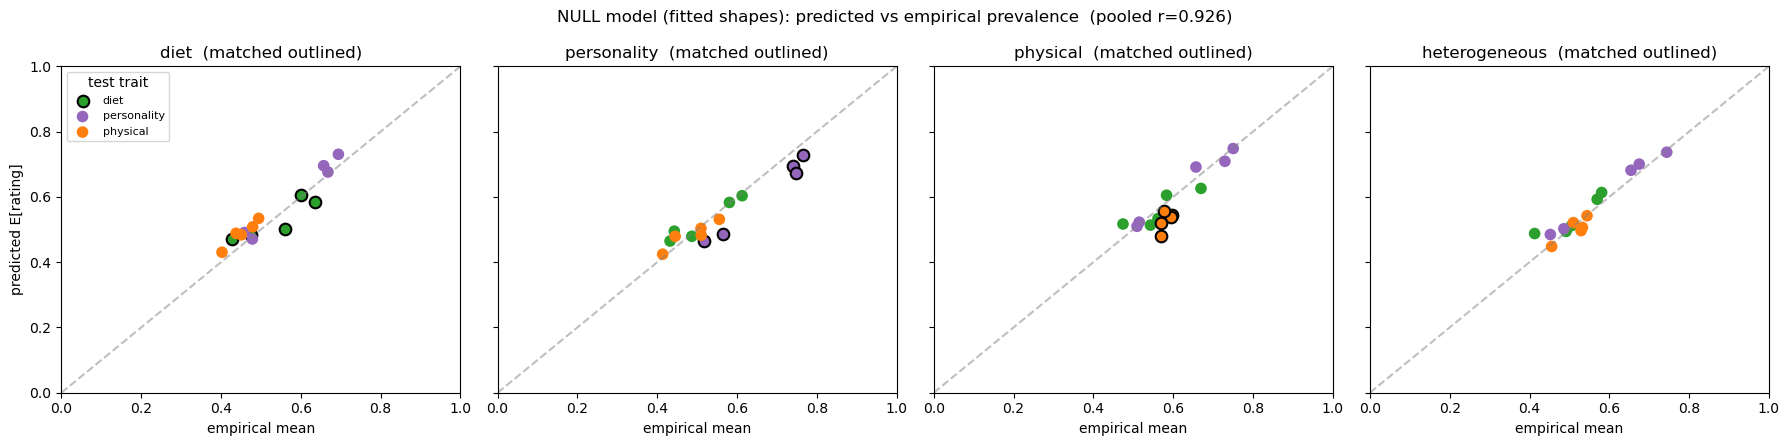

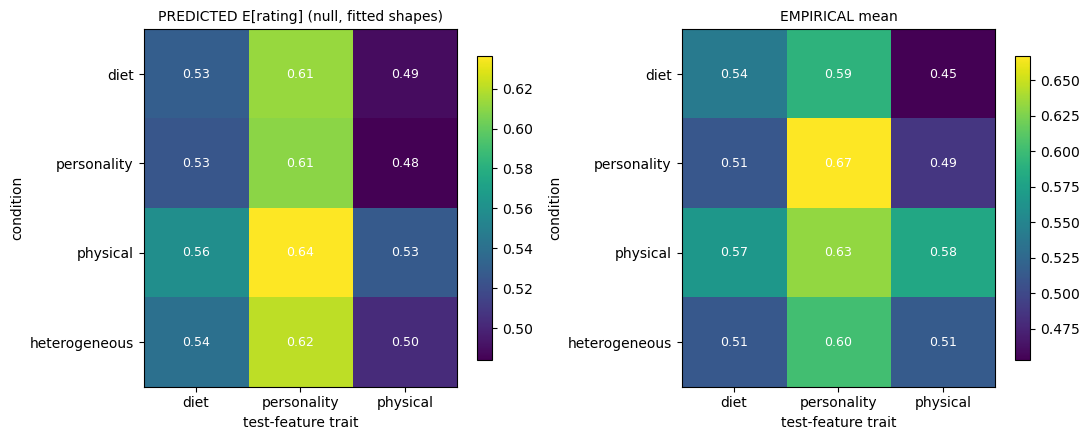

In [6]:
mu_f, sig_f = float(np.median(fit_f['mu0_samples'])), float(np.median(fit_f['sigma_samples']))
print(f"Forward pass at posterior median: ls={LS_NULL:g} (pinned), mu_0={mu_f:.3f}, sigma={sig_f:.3f}")

_, shapes_f, cond_data_f = inf.total_log_lik_free_shapes(
    geom, responses_cond, LS_NULL, mu_f, sig_f, return_shapes=True)
mean_kl_f  = shapes_f[:, 0] / (shapes_f[:, 0] + shapes_f[:, 1])
mean_nkl_f = shapes_f[:, 2] / (shapes_f[:, 2] + shapes_f[:, 3])

np.savez_compressed(os.path.join(RESULTS_DIR, 'fitted-link-shapes.npz'),
                    shapes=shapes_f, feature_names=np.array(test_feature_names),
                    theta=np.array([LS_NULL, mu_f, sig_f]))
import csv as _csv
SHAPES_CSV = os.path.join(RESULTS_DIR, 'fitted-link-shapes.csv')
with open(SHAPES_CSV, 'w', newline='') as f:
    w = _csv.writer(f)
    w.writerow(['feature', 'trait', 'a_kl', 'b_kl', 'a_nkl', 'b_nkl', 'mean_kl', 'mean_nkl'])
    for j, name in enumerate(test_feature_names):
        w.writerow([name, test_trait[j], *[f'{v:.4f}' for v in shapes_f[j]],
                    f'{mean_kl_f[j]:.4f}', f'{mean_nkl_f[j]:.4f}'])
print(f'saved fitted shapes to {SHAPES_CSV} (+ .npz with theta)')

traits = np.array(test_trait)
tcolor = {'diet': 'tab:green', 'personality': 'tab:purple', 'physical': 'tab:orange'}

pz1_mode_f, pred_cond_f = {}, {}
for c in inf.CONDITIONS:
    _, y_hat, ok = inf.laplace_log_Z(cond_data_f[c], LS_NULL, mu_f, sig_f)
    pz1_mode_f[c] = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    pred_cond_f[c] = pz1_mode_f[c]*mean_kl_f + (1-pz1_mode_f[c])*mean_nkl_f
    if not ok:
        print(f"  warning: {c} Laplace mode not cleanly converged")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, c in zip(axes, inf.CONDITIONS):
    for tr in tcolor:
        m = traits == tr
        ax.scatter(emp_cond[c][m], pred_cond_f[c][m], s=70, color=tcolor[tr],
                   edgecolor=('k' if tr == c else 'none'), linewidth=1.5, label=tr)
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{c}  (matched outlined)"); ax.set_xlabel('empirical mean')
axes[0].set_ylabel("predicted E[rating]"); axes[0].legend(fontsize=8, title='test trait')
r_all_f = np.corrcoef(np.concatenate([emp_cond[c] for c in inf.CONDITIONS]),
                      np.concatenate([pred_cond_f[c] for c in inf.CONDITIONS]))[0, 1]
fig.suptitle(f'NULL model (fitted shapes): predicted vs empirical prevalence  (pooled r={r_all_f:.3f})')
plt.tight_layout(); plt.show()

def by_trait(d):
    return np.array([[d[c][traits == tr].mean() for tr in ['diet', 'personality', 'physical']]
                     for c in inf.CONDITIONS])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, ttl in [(axes[0], by_trait(pred_cond_f), 'PREDICTED E[rating] (null, fitted shapes)'),
                     (axes[1], by_trait(emp_cond), 'EMPIRICAL mean')]:
    im = ax.imshow(mat, aspect='auto', cmap='viridis')
    ax.set_xticks(range(3)); ax.set_xticklabels(['diet', 'personality', 'physical'])
    ax.set_yticks(range(4)); ax.set_yticklabels(inf.CONDITIONS)
    ax.set_xlabel('test-feature trait'); ax.set_ylabel('condition'); ax.set_title(ttl, fontsize=10)
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='w', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()